# Exercise 9.6 — Q2: Euclidean Distance + KNN

**Lab Book §9.6 Exercise 2 (page 43):**  
> Calculate the distance between a new entry and other existing values
> using the Euclidean distance formula.

| Brightness | Saturation | Class |
|:---:|:---:|:---:|
| 40 | 20 | Red |
| 50 | 50 | Blue |
| 60 | 90 | Blue |
| 10 | 25 | Red |
| 70 | 70 | Blue |
| 60 | 10 | Red |
| 25 | 80 | Blue |

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Euclidean distance computation + 1-NN classification  
**Dataset:** `datasets/brightness_saturation.csv` (the 7-row table above)

---

## 🎯 Objective

For each new sample, compute the Euclidean distance to every point in the
training set, find the closest neighbor, and assign its class.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `05_Q2_Euclidean_Distance.ipynb` | This notebook |
| `datasets/brightness_saturation.csv` | 7-row table from lab book |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '05-KNN'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q2_Euclidean_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/05-KNN


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/05-KNN/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/brightness_saturation.csv')
print(f"Shape: {df.shape}")
display(df)
print("\nClass distribution:")
print(df['Class'].value_counts())

Shape: (7, 3)


,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue



Class distribution:
Class
Blue    4
Red     3
Name: count, dtype: int64


## 3. Define Features & Target

In [4]:
X = df[['Brightness', 'Saturation']].values
y = df['Class'].values
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (7, 2), y shape: (7,)


## 4. Visualise the Data

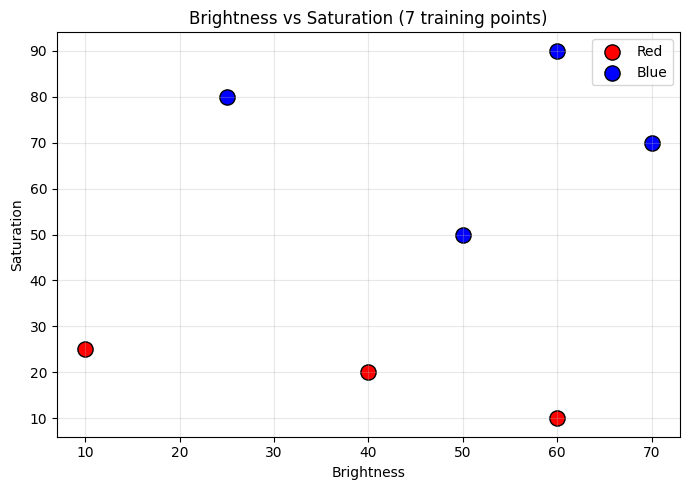

In [5]:
plt.figure(figsize=(7, 5))
colors = {'Red': 'red', 'Blue': 'blue'}
for cls in df['Class'].unique():
    sub = df[df['Class']==cls]
    plt.scatter(sub['Brightness'], sub['Saturation'],
                c=colors[cls], label=cls, s=120, edgecolors='k')
plt.xlabel('Brightness')
plt.ylabel('Saturation')
plt.title('Brightness vs Saturation (7 training points)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Define the Euclidean Distance Function

The Euclidean distance between two points $p$ and $q$ in $n$-dimensional
space is:

$$d(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

In 2-D (Brightness, Saturation):

$$d(p, q) = \sqrt{(p_B - q_B)^2 + (p_S - q_S)^2}$$

In [6]:
def euclidean(p, q):
    return np.sqrt(np.sum((np.array(p) - np.array(q)) ** 2))

# Quick sanity check
print(f"d((0,0), (3,4)) = {euclidean((0,0), (3,4))}  (should be 5.0)")

d((0,0), (3,4)) = 5.0  (should be 5.0)


## 6. Predict a New Entry Manually

In [7]:
new_entry = (45, 55)  # brightness=45, saturation=55

print(f"New entry: brightness={new_entry[0]}, saturation={new_entry[1]}")
print("\nEuclidean distances to each training point:")
print(f"{'Brightness':>10} {'Saturation':>10} {'Class':>6} {'Distance':>10}")
for i, row in df.iterrows():
    p = (row['Brightness'], row['Saturation'])
    d = euclidean(new_entry, p)
    print(f"{row['Brightness']:>10} {row['Saturation']:>10} "
          f"{row['Class']:>6} {d:>10.4f}")

# Find closest neighbor
distances = [(euclidean(new_entry, (row['Brightness'], row['Saturation'])),
             row['Class'])
            for _, row in df.iterrows()]
distances.sort()
nearest_class = distances[0][1]
print(f"\nClosest class (1-NN): {nearest_class}")

New entry: brightness=45, saturation=55

Euclidean distances to each training point:
Brightness Saturation  Class   Distance
        40         20    Red    35.3553
        50         50   Blue     7.0711
        60         90   Blue    38.0789
        10         25    Red    46.0977
        70         70   Blue    29.1548
        60         10    Red    47.4342
        25         80   Blue    32.0156

Closest class (1-NN): Blue


## 7. Verify with scikit-learn's KNeighborsClassifier (K=1)

In [8]:
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X, y)
sklearn_pred = knn.predict([new_entry])[0]
print(f"sklearn 1-NN prediction: {sklearn_pred}")
print(f"Manual 1-NN prediction: {nearest_class}")
assert sklearn_pred == nearest_class
print("✓ Manual implementation matches scikit-learn!")

sklearn 1-NN prediction: Blue
Manual 1-NN prediction: Blue
✓ Manual implementation matches scikit-learn!


## 📚 Key Takeaways
- The Euclidean distance is the default metric for KNN.
- A small dataset (7 rows) lets us verify the manual computation
  against scikit-learn.
- 1-NN with Euclidean distance is sensitive to outliers — for larger
  datasets, use K = 3, 5, or 7 to smooth out noise.
